<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/Lab-3%20Multiple%20Linear%20Regression%20using%20Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Exercise 3
### Linear regression: Implement multiple linear regression using perceptron.

Link for dataset: https://www.kaggle.com/datasets/hussainnasirkhan/multiple-linear-regression-dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving multiple_linear_regression_dataset.csv to multiple_linear_regression_dataset.csv


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("multiple_linear_regression_dataset.csv")
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         20 non-null     int64
 1   experience  20 non-null     int64
 2   income      20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,age,experience,income
count,20.000000,20.000000,20.000000
mean,39.650000,6.200000,40735.500000
std,10.027725,4.124382,8439.797625
min,23.000000,1.000000,27840.000000
25%,31.500000,3.750000,35452.500000
50%,40.000000,5.000000,40190.000000
75%,47.000000,9.000000,45390.000000
max,58.000000,17.000000,63600.000000


- From initial inspection of the dataset, we come to know that there are no missing values.
- Now we check the probability distribution of the features.

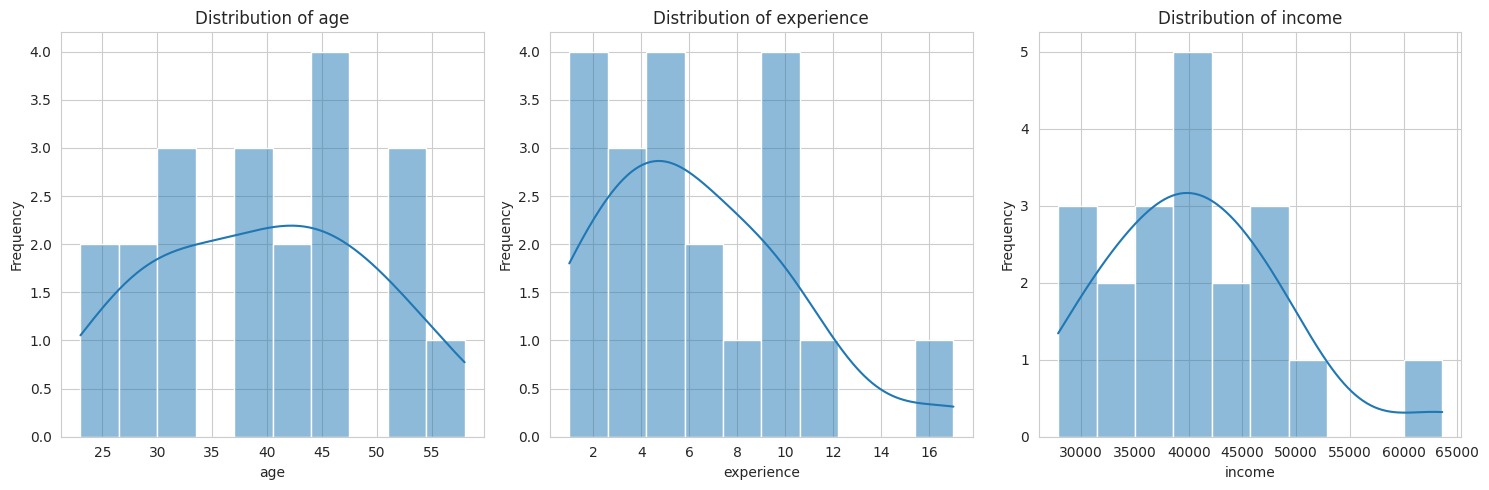

In [ ]:
# Set the visual style
sns.set_style("whitegrid")

# Create a figure for the plots
plt.figure(figsize=(15, 5))

# Plot distribution for each column
features = ['age', 'experience', 'income']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=10) # kde=True adds the probability curve
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

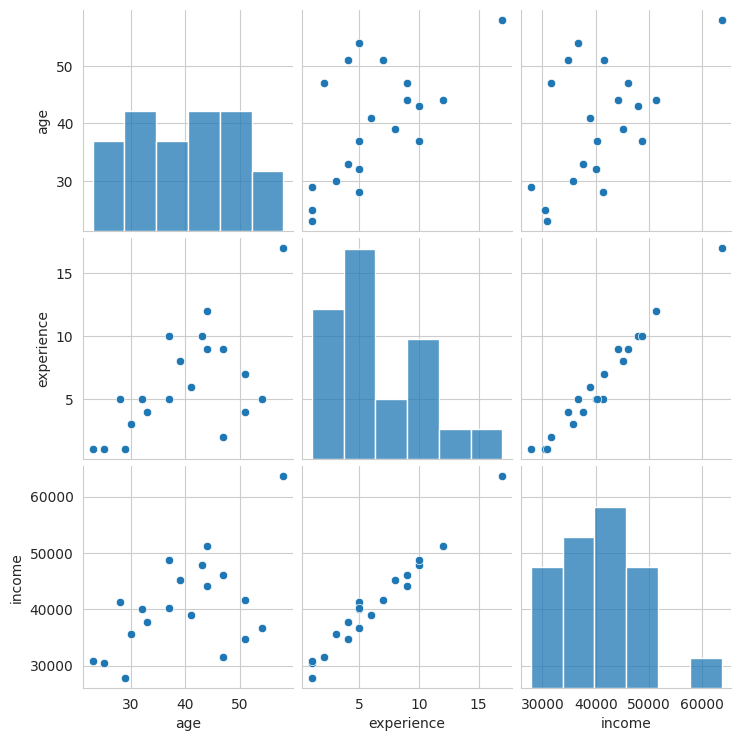

In [ ]:
# Visualizing relationships between variables
sns.pairplot(df)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate the features and the target
X = df[['age', 'experience']].values
y = df['income'].values

# Reshape y to (n_samples, 1) to match matrix operations
y = df['income'].values.reshape(-1, 1)

# Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled  = sc_X.transform(X_test)
y_train_scaled = sc_y.fit_transform(y_train)
y_test_scaled  = sc_y.transform(y_test)

# Custom Single Layer Perceptron (Linear Activation)
class PerceptronRegression:
    def __init__(self, learning_rate=0.001, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for epoch in range(self.epochs):
            # Forward Pass: y = WX + b
            y_pred = np.dot(X, self.weights) + self.bias

            # Gradient Descent
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            # Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Track MSE Loss
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train and Evaluate
model = PerceptronRegression(learning_rate=0.01, epochs=1000)
model.fit(X_train_scaled, y_train_scaled)

# Prediction & Inverse Scaling
y_pred_scaled = model.predict(X_test_scaled)
y_pred = sc_y.inverse_transform(y_pred_scaled)

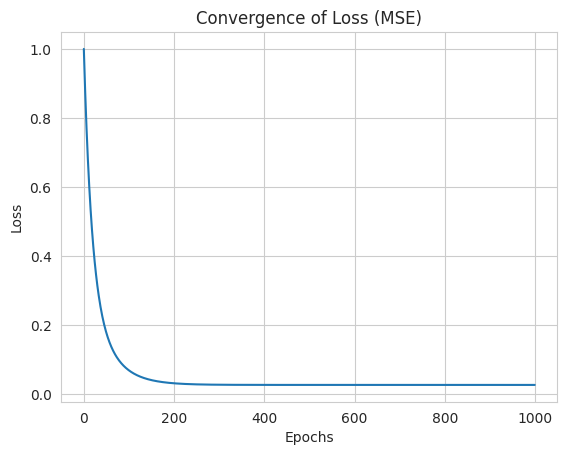

RMSE: 868.2125
R2 Score: 0.9387
Weight for Age: -0.1079
Weight for Experience: 1.0325


In [ ]:
# Plot the Learning Curve
plt.plot(model.loss_history)
plt.title("Convergence of Loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Compare Predictions
from sklearn.metrics import r2_score, mean_squared_error
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")


# Check the learned weights
print(f"Weight for Age: {model.weights[0][0]:.4f}")
print(f"Weight for Experience: {model.weights[1][0]:.4f}")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Train the Scikit-Learn Model
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train_scaled)

# Get Predictions
# Perceptron predictions (already in y_pred)
# Sklearn predictions:
y_pred_sk_scaled = sk_model.predict(X_test_scaled)
y_pred_sk = sc_y.inverse_transform(y_pred_sk_scaled)

# Print the Comparison
print("PERCEPTRON (Manual Gradient Descent) ")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Weights (Age, Exp): {model.weights.flatten()}")
print(f"Bias: {model.bias:.4f}")

print("\nSKLEARN (Ordinary Least Squares)")
print(f"R2 Score: {r2_score(y_test, y_pred_sk):.4f}")
print(f"Weights (Age, Exp): {sk_model.coef_.flatten()}")
print(f"Bias: {sk_model.intercept_[0]:.4f}")

PERCEPTRON (Manual Gradient Descent) 
R2 Score: 0.9387
Weights (Age, Exp): [-0.10787613  1.03250895]
Bias: -0.0000

SKLEARN (Ordinary Least Squares)
R2 Score: 0.9387
Weights (Age, Exp): [-0.10788829  1.03252111]
Bias: -0.0000


Results' Interpretation:

- **Convergence Achievement:** The identical R2 Score of 0.9387 confirms that your Gradient Descent reached the global minimum.

- **Feature Importance:** Both models show a weight of approximately 1.03 for Experience and -0.11 for Age. This indicates that in this dataset, professional experience is the primary positive driver of income, while age has a slight negative correlation when experience is held constant.